In [1]:
from sklearn.datasets import fetch_openml
mnist=fetch_openml('mnist_784',version=1)

In [2]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [3]:
# load the data 
X=mnist['data'].to_numpy()
X.shape

(70000, 784)

In [4]:
Y=mnist['target'].to_numpy()
Y.shape

(70000,)

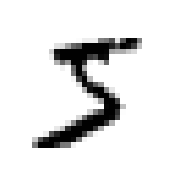

In [5]:
import matplotlib as mpl 
import matplotlib.pyplot as plt
some_digit=X[0]
some_digit_image=some_digit.reshape(28,28)
plt.figure(figsize=(3,2))
plt.imshow(some_digit_image,cmap="binary")
plt.axis("off")
plt.show()

In [8]:
Y[0]

'5'

In [9]:
#since ML algorithms like number we will typecast the target value into integers
import numpy as np
Y=Y.astype(np.uint8)

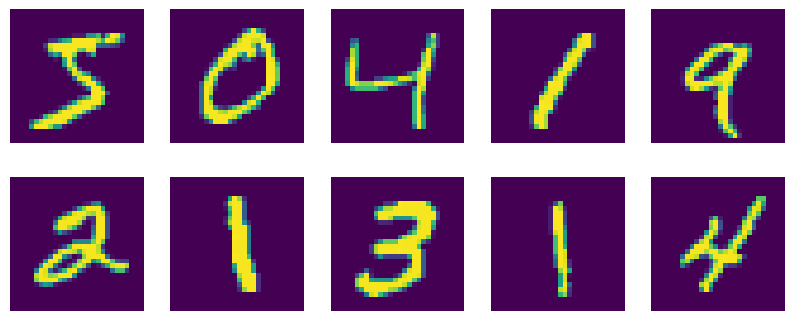

In [10]:
fig,axes=plt.subplots(2, 5, figsize=(10, 4))
for i,ax in enumerate(axes.flatten()):
    number = X[i].reshape(28,28)
    ax.imshow(number)
    ax.axis('off')
plt.show()

In [11]:
# mnist ds already has 60k rows for training and 10k rows for testing split and stratified before hand 
X_train,X_test,y_train,y_test=X[:60000],X[60000:],Y[:60000],Y[60000:]

In [12]:
# let's train a model to only classify 5 or not 5
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train_5)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

In [13]:
sgd_clf.predict([X[1]])

array([False])

In [14]:
# making my own straitified model wihtout using cross_val_split 
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
clone_sgd = clone(sgd_clf)
skfolds = StratifiedKFold(n_splits=3,random_state=42,shuffle=True)
for train_i,test_i in skfolds.split(X_train,y_train):
    X_train_folds=X_train[train_i]
    Y_train_folds=y_train_5[train_i]
    X_test_folds=X_train[test_i]
    Y_test_folds=y_train_5[test_i]
    clone_sgd.fit(X_train_folds,Y_train_folds)
    fold_pred = clone_sgd.predict(X_test_folds)
    correct_res = sum(fold_pred == Y_test_folds)
    acc = correct_res/len(X_test_folds)
    print('accuracy : ',acc)

accuracy :  0.9701
accuracy :  0.9614
accuracy :  0.9586


In [15]:
# same thing but using cross_val_score
from sklearn.model_selection import cross_val_score
scores=cross_val_score(sgd_clf,X_train,y_train,scoring='accuracy',cv=3)
scores

array([0.87745, 0.85835, 0.8698 ])

In [16]:
# the above accuracy rates might look good on paper but all we did was classify 5 or not 5 and considering the number of actual fives in the dataset if the model simple predicted everything as not 5 it would still get a good accuracy. Lets put this to the test by writing a really dumb classifier 
from sklearn.base import BaseEstimator
class Never5Classifier(BaseEstimator):
    def fit(self,X,y=None):
        # since its a dumb model we dont need it to learn any patterns in data so lets return nothing
        return self
    def predict(self,X):
        return np.zeros((len(X),1),dtype=bool)

In [17]:
# see the dumb model that just predicted all values as not 5 has a high accuracy.
# This is why we cant use accuracy to measure the performance of a classifier model 
dumb_never_5_classifier=Never5Classifier()
cross_val_score(dumb_never_5_classifier,X_train,y_train_5,cv=3,scoring='accuracy')

array([0.91125, 0.90855, 0.90915])

### Using Confusion Matrix

In [18]:
#use confusion matrix to get to know about the actual performance of a ML model
from sklearn.model_selection import cross_val_predict
# using cross_val_predict to where the model is making mistakes so as to be able to feed this into the confusion matrix
y_train_pred = cross_val_predict(sgd_clf,X_train,y_train_5,cv=3)

In [19]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5,y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

In [20]:
# we even have metrics such as precision and recall
from sklearn.metrics import precision_score,recall_score
# precision = TP / (TP+FP)
print('precision_score : ',precision_score(y_train_5,y_train_pred))
# recall = TP / (TP+FN)
print('recall_score : ',recall_score(y_train_5,y_train_pred))

precision_score :  0.8370879772350012
recall_score :  0.6511713705958311


In [21]:
# to calc precision and recall together use F1 score 
# f1 score = 2 * (precision*recall)/(precision+recall) 
from sklearn.metrics import f1_score
f1_score(y_train_5,y_train_pred)

0.7325171197343847

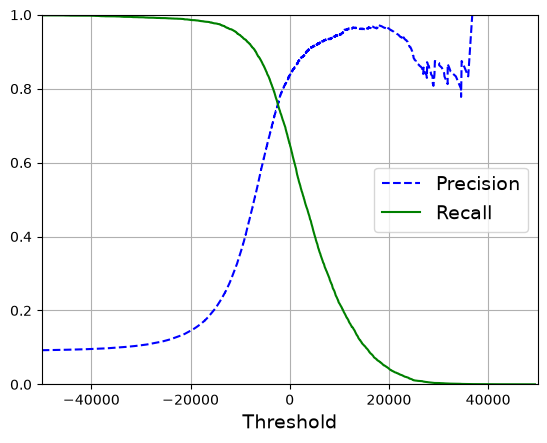

In [22]:
# plotting the precision recall vs threshold graph
from sklearn.metrics import precision_recall_curve
y_scores=cross_val_predict(sgd_clf,X_train,y_train_5,cv=3,method="decision_function")
precision,recall,threshold=precision_recall_curve(y_train_5,y_scores)
def plot_precision_recall_vs_threshold(p,r,t):
    # plot precision with blue dotted line
    plt.plot(t,p[:-1],"b--",label="Precision")
    # plot recall with green solid line
    plt.plot(t,r[:-1],"g-",label="Recall")
    plt.xlabel("Threshold", fontsize=14)
    plt.legend(loc="center right", fontsize=14) # Shows the legend box
    plt.grid(True)                            # Adds a background grid for readability
    plt.axis([-50000, 50000, 0, 1])
plot_precision_recall_vs_threshold(precision,recall,threshold)
plt.show()

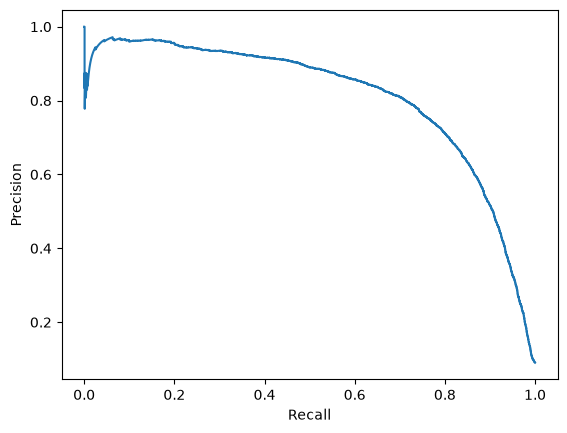

In [23]:
plt.plot(recall,precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

### The ROC Curve

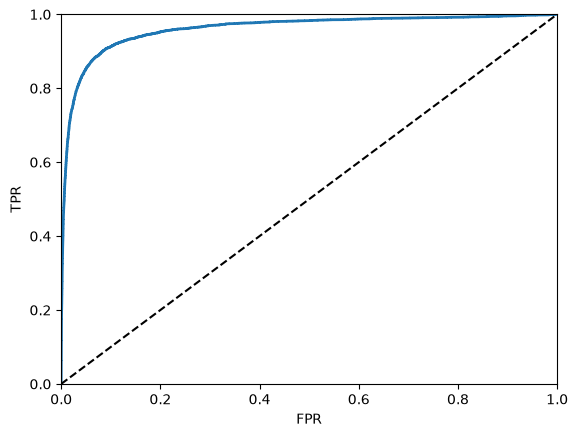

In [24]:
from sklearn.metrics import roc_curve
fpr,tpr,threshold = roc_curve(y_train_5,y_scores)
def plot_roc_curve(fpr,tpr,label=None):
    plt.plot(fpr,tpr,linewidth=2,label=label)
    plt.plot([0,1],[0,1],'k--')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('FPR')
    plt.ylabel('TPR')
plot_roc_curve(fpr,tpr)

### Get the Area under the curve to know the real performance of classifier model - closer to 1 the better

In [25]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5,y_scores)

0.9604938554008616

In [26]:
# compare random forest with the SGD Classifier model
from sklearn.ensemble import RandomForestClassifier
rand_forest_clf = RandomForestClassifier()
y_score_forest = cross_val_predict(rand_forest_clf,X_train,y_train_5,cv=3,method='predict_proba')

In [27]:
y_score_forest = y_score_forest[:,1]

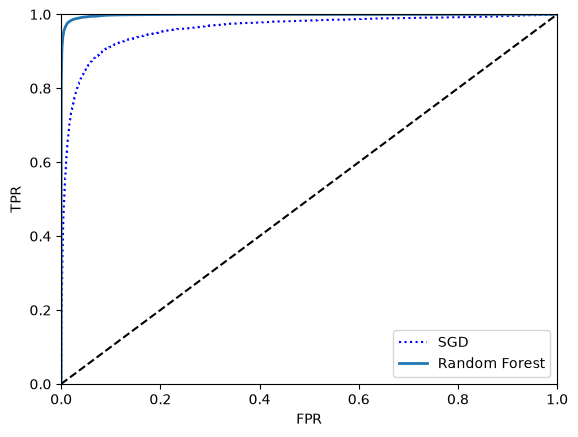

In [28]:
fpr_forest,tpr_forest,threshold_forest = roc_curve(y_train_5,y_score_forest)
plt.plot(fpr,tpr,"b:",label="SGD")
plot_roc_curve(fpr_forest,tpr_forest,"Random Forest")
plt.legend(loc="lower right")
plt.show()

In [29]:
# check the AUC of  random forest algo 
roc_auc_score(y_train_5,y_score_forest)

0.9983488104763305

In [30]:
# Lets train a simple Support vector classifier
# lets now do the multi class classification
from sklearn.svm import SVC
svm_clf = SVC()
svm_clf.fit(X_train,y_train)
svm_clf.predict([some_digit])

array([5], dtype=uint8)

In [31]:
some_digits_score = svm_clf.decision_function([some_digit])
some_digits_score


array([[ 1.72501977,  2.72809088,  7.2510018 ,  8.3076379 , -0.31087254,
         9.3132482 ,  1.70975103,  2.76765202,  6.23049537,  4.84771048]])

In [32]:
# cross check the output
np.argmax(some_digits_score)

np.int64(5)

In [33]:
svm_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [34]:
svm_clf.classes_[5].tolist()

5

In [35]:
# by deafault sklearn will use the One vs One classifier but if u dont want the default behavious you can override it 
from sklearn.multiclass import OneVsRestClassifier
ovr_clf = OneVsRestClassifier(SVC(),n_jobs=-1)
ovr_clf.fit(X_train,y_train)
ovr_clf.predict([some_digit])

array([5], dtype=uint8)

In [36]:
len(ovr_clf.estimators_)

10

In [38]:
# train the sgd or random forest model for multi classification and see the scores
sgd_clf.fit(X_train,y_train)
sgd_clf.predict([some_digit])

array([3], dtype=uint8)

In [39]:
sgd_clf.decision_function([some_digit])

array([[-31893.03095419, -19047.55566534,  -9530.63950739,
          1823.73154031, -22320.14822878,  -1385.80478895,
        -26188.91070951, -16147.51323997,  -4604.35491274,
        -12050.767298  ]])

In [54]:
sgd_clf.predict([X_train[25]])

array([8], dtype=uint8)

In [48]:
[y_train[25]]

[np.uint8(2)]

In [ ]:
test_image = X_train[0].reshape(28,28)
plt.imshow(test_image)

In [65]:
cross_val_score(sgd_clf,X_train,y_train,cv=3,scoring="accuracy")

array([0.87745, 0.85835, 0.8698 ])

In [73]:
# scale the data so that we get a better accuracy
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf,X_train_scaled,y_train,cv=3,scoring="accuracy")

C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([0.89835, 0.8902 , 0.90095])

In [75]:
# plot confusion matrix
y_train_pred = cross_val_predict(sgd_clf,X_train_scaled,y_train,cv=3,n_jobs=-1)
conf_mx = confusion_matrix(y_train,y_train_pred)
conf_mx

array([[5573,    0,   23,    5,    8,   44,   36,    6,  227,    1],
       [   0, 6398,   37,   24,    4,   43,    4,    7,  214,   11],
       [  29,   25, 5220,   91,   73,   25,   68,   36,  380,   11],
       [  22,   17,  117, 5224,    2,  204,   27,   40,  405,   73],
       [  12,   14,   40,    9, 5181,   12,   34,   25,  351,  164],
       [  26,   15,   29,  165,   53, 4445,   74,   14,  541,   59],
       [  30,   15,   43,    3,   43,   96, 5551,    3,  133,    1],
       [  20,    9,   51,   29,   49,   12,    3, 5680,  200,  212],
       [  18,   64,   47,   89,    3,  124,   25,   10, 5426,   45],
       [  23,   18,   30,   65,  117,   37,    1,  179,  387, 5092]])

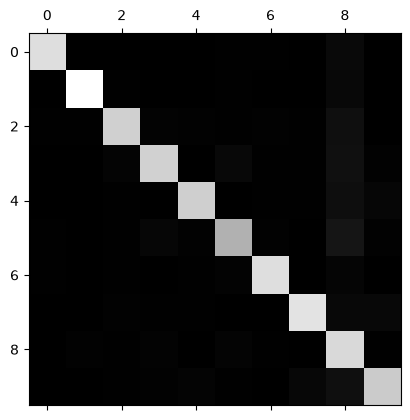

In [76]:
plt.matshow(conf_mx,cmap=plt.cm.gray)
plt.show()

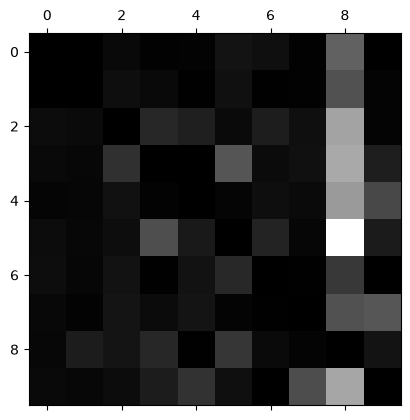

In [80]:
# find out where the error comes
row_sum = conf_mx.sum(axis=1,keepdims=True)
# normalize by dividing all values with the sum of total
norm_conf_mx = conf_mx/row_sum
# make diagonals 0 since it rep correct predictions 
np.fill_diagonal(norm_conf_mx,0)
plt.matshow(norm_conf_mx,cmap= plt.cm.gray)
plt.show()

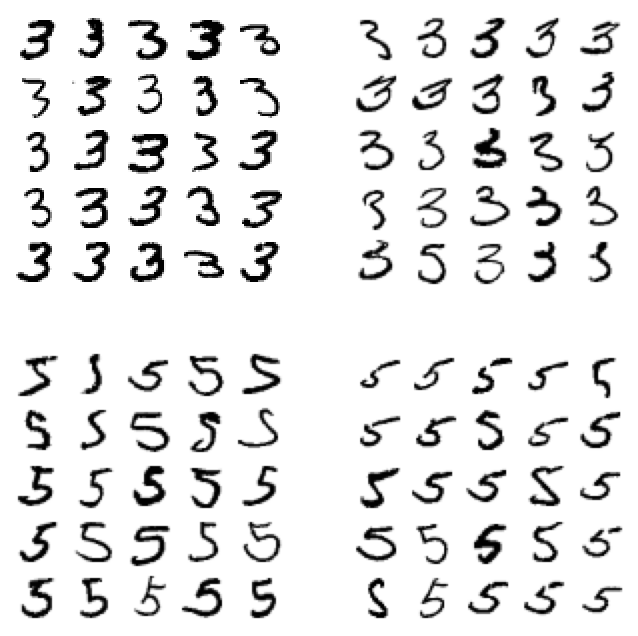

In [85]:
#
def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    # Number of rows needed
    n_rows = (len(instances) - 1) // images_per_row + 1
    
    # Pad empty slots if the last row isn't full
    n_empty = n_rows * images_per_row - len(instances)
    padded_instances = np.concatenate([instances, np.zeros((n_empty, size * size))], axis=0)
    
    # Reshape the array to a grid
    image_grid = padded_instances.reshape((n_rows, images_per_row, size, size))
    
    # Combine axes to form one large image
    big_image = image_grid.transpose(0, 2, 1, 3).reshape(n_rows * size, images_per_row * size)
    
    # Plot it
    plt.imshow(big_image, cmap=plt.cm.binary, **options)
    plt.axis("off")
cl_a,cl_b = 3,5
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]
plt.figure(figsize=(8,8))
plt.subplot(221); plot_digits(X_aa[:25], images_per_row=5)
plt.subplot(222); plot_digits(X_ab[:25], images_per_row=5)
plt.subplot(223); plot_digits(X_ba[:25], images_per_row=5)
plt.subplot(224); plot_digits(X_bb[:25], images_per_row=5)
plt.show()


In [87]:
# lets write code for multi label classificatin
from sklearn.neighbors import KNeighborsClassifier
y_train_large = (y_train >=7)
y_train_odd = (y_train % 2 == 1)
y_train_multilabel = np.c_[y_train_large,y_train_odd]
k_clf = KNeighborsClassifier(n_jobs=-1)
k_clf.fit(X_train,y_train_multilabel)

,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",-1
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier",list,"[array([False, True]), array([False, True])]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [93]:
sample_data = 10
print('Actual : ',y_train[sample_data])
k_clf.predict([X_train[sample_data]])

Actual :  3


array([[False,  True]])

In [ ]:
# the above model performs a really good job in classifying all data 
# let us test this now by taking the avg f1 scores of all the classification of instances 
y_train_multilabel_pred = cross_val_predict(k_clf,X_train,y_train_multilabel,cv=3,n_jobs=-1)

In [95]:
f1_score(y_train_multilabel,y_train_multilabel_pred,average="weighted")

0.9778357403921755

In [96]:
f1_score(y_train_multilabel,y_train_multilabel_pred,average="macro")

0.9764102655606048

### Multioutput classification model

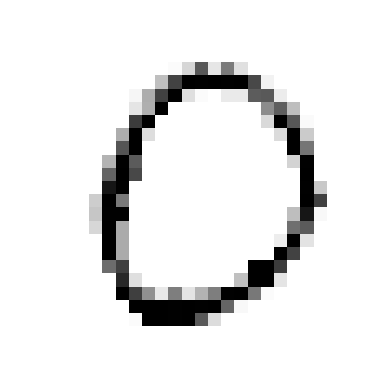

In [99]:
# Goal is to add noise into the image and try to retreive the original image 
noise = np.random.randint(0,100,(len(X_train),784))
X_train_mod = X_train + noise
noise = np.random.randint(0,100,(len(X_test),784))
X_test_mod = X_test + noise
y_train_mod = X_train 
y_test_mod = X_test
k_clf.fit(X_train_mod,y_train_mod)
clean_digit = k_clf.predict([X_test_mod[sample_data]])
plot_digits(clean_digit)

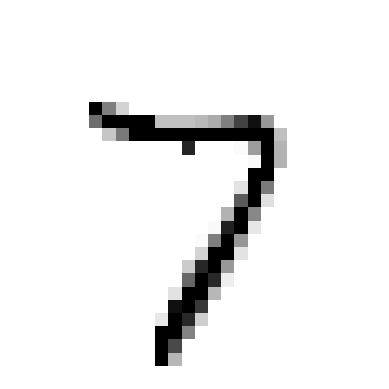

In [104]:
clean_digit = k_clf.predict([X_test_mod[0]])
plot_digits(clean_digit)